# Tool Calling

### Problem Statement

Build a **multi-tool AI assistant using LangGraph in Python** that can dynamically use a custom calculator, weather API, and Google Search tool to answer user questions.

The workflow should:

1. Accept a user question that may require one or more tools.
2. Provide the LLM with access to three tools:
   - A **custom calculator** for mathematical calculations.
   - A **weather API** for retrieving current weather information for a city.
   - A **Google Search** tool for retrieving up-to-date information from the web.
3. Allow the LLM to decide which tool to use based on the user's question.
4. Execute the selected tool using LangGraph's **ToolNode**.
5. Pass the tool result back to the LLM.
6. Allow the LLM to call additional tools when the answer requires multiple steps or different sources.
7. Continue the **LLM → Tool → LLM** loop until the LLM has enough information to answer the user.
8. End when the LLM produces a final response without requesting another tool.
9. Maintain the conversation and tool results in the LangGraph state.

**Example:**

For a question such as:

> "What is the temperature in Mumbai and Delhi, and what is the percentage difference between them?"

The assistant should:

1. Retrieve the temperature of Mumbai using the weather tool.
2. Retrieve the temperature of Delhi using the weather tool.
3. Use the calculator tool to calculate the percentage difference.
4. Provide the final answer to the user.

**Workflow:**

```text
START → LLM → ToolNode → LLM → ToolNode → ... → LLM → END
                 ↑                       │
                 └───────────────────────┘
                  (if another tool is needed)


In [231]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from typing import TypedDict, Literal, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_community.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
import requests
import os
from langsmith import traceable
import json

In [213]:
os.environ["LANGSMITH_PROJECT"] = "Langgraph tools calling"
os.environ["LANGSMITH_TRACING"] = "true"


In [214]:
load_dotenv()

True

In [215]:
os.environ["LANGSMITH_PROJECT"]

'Langgraph tools calling'

In [216]:
model = ChatOpenAI(model='gpt-5.4-mini')

#### Calculator Tool

In [217]:
@tool
@traceable
def calculator(first_num: int, second_num: int, operation: Literal["ADD", "MUL", "SUB", "DIV"]) -> dict:
    """
    This is calculator tools.
    Input: 2 float numbers
    Output: dictionary of first_num, second_num, operation, result
    Supported Operations: "ADD", "MUL", "SUB", "DIV"
    """

    try:
        if operation == "ADD":
            result = first_num + second_num
        elif operation == "MUL":
            result = first_num * second_num
        elif operation == "SUB":
            result = first_num - second_num
        elif operation == "DIV":
            result = first_num / second_num
        else:
            return {"error": f"Unsupported Operation {operation}."}
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}
    

#### Search Tool

In [218]:
search_tool = DuckDuckGoSearchRun(region="us-en")

#### Weather API Tool

In [219]:
@tool
@traceable
def weather_tool(city: str) -> dict:
    """
    This is the weather tool, it takes city name and returns the current weather of that city. 
    """
    try:
        api_key = os.environ["WEATHER_API_KEY"]
        url = "https://api.openweathermap.org/data/2.5/weather"
    
        params = {
            "q": city,
            "appid": api_key
        }
    
        response = requests.get(url, params=params)
        data = response.json()
    
        return data
    except Exception as e:
        return {"error": str(e)}

In [232]:
class ChatState(TypedDict):
    messages: Annotated[[BaseMessage], add_messages]

In [233]:
tools = [weather_tool, search_tool, calculator]

llm_with_tools = model.bind_tools(tools)

In [264]:
def get_message(state: ChatState):
    query = state['messages']

    res = llm_with_tools.invoke(f"you are helpful assistant. respond to the users query in natural language. query: {query}")

    return {"messages": [res]}

In [265]:
tools_node = ToolNode(tools)

In [266]:
graph = StateGraph(ChatState)

In [267]:
graph.add_node("get_message", get_message)
graph.add_node("tools", tools_node)

graph.add_edge(START, "get_message")
graph.add_conditional_edges("get_message", tools_condition)
graph.add_edge("tools", "get_message")
graph.add_edge("get_message", END)

workflow = graph.compile()



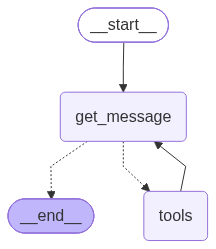

In [268]:
workflow

In [269]:
res = workflow.invoke({"messages": [HumanMessage("what is the center of india?")]})

In [270]:
res['messages'][-1].content

'The geographic center of India is generally considered to be near **Karaundi village in Seoni district, Madhya Pradesh**.\n\nA small marker/monument there is often referred to as the **“Zero Mile Centre”** or a central point of India, though different definitions of “center” can vary slightly depending on whether you mean:\n\n- **Geographic center**\n- **Center based on political boundaries**\n- **Center by population**\n\nIf you want, I can also explain **how the center was determined** or show it on a map.'

In [271]:
res = workflow.invoke({"messages": [HumanMessage("what is 1+22")]})

In [272]:
res['messages'][-1].content

'1 + 22 = 23'

In [274]:
res = workflow.invoke({"messages": [HumanMessage("what is pune's current temperature")]})
res['messages'][-1].content

'Pune’s current temperature is **298.62 K**, which is about **25.5°C**.  \nIt’s currently **broken clouds** there.'

In [275]:
res = workflow.invoke({"messages": [HumanMessage("what is capital of india")]})
res['messages'][-1].content

'The capital of India is **New Delhi**.'

In [276]:
res = workflow.invoke({"messages": [HumanMessage("find the capital of india and give me the weather and it's multiplication by 2")]})
res['messages'][-1].content

'The capital of India is **New Delhi**.\n\nCurrent weather in New Delhi:\n- **Condition:** Few clouds\n- **Temperature:** **306.16 K** (about **33.0°C**)\n- **Feels like:** **313.16 K** (about **40.0°C**)\n\nIf you mean the temperature multiplied by 2:\n- **306 × 2 = 612**'